# Assignment 2: Credit Card Default Prediction

This notebook uses the **UCI Default of Credit Card Clients** dataset to compare two tabular classifiers on the same problem:

- a **PyTorch MLP with embeddings** for categorical features
- a **CatBoost** tree-based model, plus a random forest baseline for reference

The deployment lives in `assignment2_credit_default/`, and the local dataset file is `data/credit_card_default/default_of_credit_card_clients.csv`.


In [1]:
from pathlib import Path
import json
import subprocess
import sys

import joblib
import pandas as pd
from IPython.display import Image, display

REPO_ROOT = Path.cwd()
PROJECT_ROOT = REPO_ROOT / 'assignment2_credit_default'
ARTIFACTS_DIR = PROJECT_ROOT / 'artifacts'
MODELS_DIR = PROJECT_ROOT / 'models'
NOTEBOOK_ASSETS_DIR = PROJECT_ROOT / 'notebook_assets'

sys.path.append(str(PROJECT_ROOT))

from src.data_utils import load_credit_default_data, split_credit_default_data, build_mlp_metadata
from src.config import CATEGORICAL_COLUMNS, NUMERICAL_COLUMNS

print(f'Repo root: {REPO_ROOT}')
print(f'Project root: {PROJECT_ROOT}')

Repo root: /Users/osmancamara/Documents/python_utvecklare_inom_AI/ML/ml-1-course-kedy92
Project root: /Users/osmancamara/Documents/python_utvecklare_inom_AI/ML/ml-1-course-kedy92/assignment2_credit_default


## 1. Data Exploration

The dataset contains 30,000 Taiwanese credit-card clients and a binary target indicating whether the client defaulted in the next month. It mixes demographic categories with financial history and payment behavior.


In [2]:
df = load_credit_default_data()
print(df.shape)
display(df.head())

summary = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing_values': df.isna().sum(),
    'n_unique': df.nunique(),
})
display(summary)

class_balance = df['default_next_month'].value_counts(normalize=True).rename('share').to_frame()
class_balance.index = ['No default', 'Default']
display(class_balance)

(30000, 24)


,limit_bal,sex,education,marriage,age,pay_0,pay_2,pay_3,pay_4,pay_5,...,bill_amt4,bill_amt5,bill_amt6,pay_amt1,pay_amt2,pay_amt3,pay_amt4,pay_amt5,pay_amt6,default_next_month
0,20000,female,university,married,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,female,university,single,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,female,university,single,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,female,university,married,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,male,university,married,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


,dtype,missing_values,n_unique
limit_bal,int64,0,81
sex,object,0,2
education,object,0,5
marriage,object,0,4
age,int64,0,56
pay_0,int64,0,11
pay_2,int64,0,11
pay_3,int64,0,11
pay_4,int64,0,11
pay_5,int64,0,10


,share
No default,0.7788
Default,0.2212


In [3]:
categorical_preview = pd.DataFrame({
    col: df[col].value_counts().sort_index() for col in CATEGORICAL_COLUMNS
}).fillna(0).astype(int)
display(categorical_preview)

financial_summary = df[NUMERICAL_COLUMNS].describe().T[['mean', 'std', 'min', 'max']]
display(financial_summary.head(10))

,sex,education,marriage
female,18112,0,0
graduate_school,0,10585,0
high_school,0,4917,0
male,11888,0,0
married,0,0,13659
other,0,123,323
single,0,0,15964
university,0,14030,0
unknown,0,345,54


,mean,std,min,max
limit_bal,167484.322667,129747.661567,10000.0,1000000.0
age,35.485500,9.217904,21.0,79.0
pay_0,-0.016700,1.123802,-2.0,8.0
pay_2,-0.133767,1.197186,-2.0,8.0
pay_3,-0.166200,1.196868,-2.0,8.0
pay_4,-0.220667,1.169139,-2.0,8.0
pay_5,-0.266200,1.133187,-2.0,8.0
pay_6,-0.291100,1.149988,-2.0,8.0
bill_amt1,51223.330900,73635.860576,-165580.0,964511.0
bill_amt2,49179.075167,71173.768783,-69777.0,983931.0


## 2. Train / Validation / Test Split

I kept a proper holdout test set, then split the remaining data again for validation. That lets the MLP tune on validation data and keeps the final comparison honest.


In [4]:
splits = split_credit_default_data(df)
split_summary = pd.DataFrame(
    {
        'rows': [len(splits.train), len(splits.val), len(splits.test)],
        'default_rate': [
            splits.train['default_next_month'].mean(),
            splits.val['default_next_month'].mean(),
            splits.test['default_next_month'].mean(),
        ],
    },
    index=['train', 'validation', 'test'],
)
display(split_summary)

print('Categorical columns:', CATEGORICAL_COLUMNS)
print('Numerical columns:', NUMERICAL_COLUMNS)

,rows,default_rate
train,19200,0.221198
validation,4800,0.221250
test,6000,0.221167


Categorical columns: ['sex', 'education', 'marriage']
Numerical columns: ['limit_bal', 'age', 'pay_0', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6', 'bill_amt1', 'bill_amt2', 'bill_amt3', 'bill_amt4', 'bill_amt5', 'bill_amt6', 'pay_amt1', 'pay_amt2', 'pay_amt3', 'pay_amt4', 'pay_amt5', 'pay_amt6']


## 3. Preprocessing Choices

For the MLP, I use learned embeddings on the three real categorical variables and standard scaling on numerical columns. For the tree model, CatBoost handles categorical columns directly, while the random forest baseline uses one-hot encoding.


In [5]:
mlp_metadata = build_mlp_metadata(splits.train)
metadata_preview = {
    'categorical_columns': mlp_metadata['categorical_columns'],
    'numerical_columns': mlp_metadata['numerical_columns'][:5],
    'category_maps': {col: mlp_metadata['inverse_category_maps'][col] for col in CATEGORICAL_COLUMNS},
}
metadata_preview

{'categorical_columns': ['sex', 'education', 'marriage'],
 'numerical_columns': ['limit_bal', 'age', 'pay_0', 'pay_2', 'pay_3'],
 'category_maps': {'sex': ['__UNK__', 'female', 'male'],
  'education': ['__UNK__',
   'graduate_school',
   'high_school',
   'other',
   'university',
   'unknown'],
  'marriage': ['__UNK__', 'married', 'other', 'single', 'unknown']}}

## 4. Training Pipelines

The heavy training run is already saved under `assignment2_credit_default/models/` and `assignment2_credit_default/artifacts/`. The cell below reruns the full pipeline only if those artifacts are missing.


In [6]:
required_files = [
    ARTIFACTS_DIR / 'comparison_table.csv',
    MODELS_DIR / 'mlp_model.pt',
    MODELS_DIR / 'catboost_model.joblib',
]

if all(path.exists() for path in required_files):
    print('Saved artifacts already exist. Skipping retraining.')
else:
    subprocess.run(
        [sys.executable, str(PROJECT_ROOT / 'train_models.py')],
        check=True,
        cwd=REPO_ROOT,
        env={**dict(), **__import__('os').environ, 'MPLCONFIGDIR': str(ARTIFACTS_DIR / 'mpl')},
    )

Saved artifacts already exist. Skipping retraining.


## 5. MLP With Embeddings

I tried three MLP configurations, keeping the preprocessing and split fixed. The best validation AUC came from the wider two-layer network.


In [7]:
mlp_tuning = pd.read_csv(ARTIFACTS_DIR / 'mlp_tuning_results.csv')
display(mlp_tuning)

mlp_test_metrics = json.loads((ARTIFACTS_DIR / 'mlp_test_metrics.json').read_text())
pd.Series({k: v for k, v in mlp_test_metrics.items() if k not in {'classification_report', 'confusion_matrix'}})


,config_name,hidden_dims,dropout,learning_rate,batch_size,val_auc,val_f1,test_auc,test_f1
0,baseline,"[64, 32]",0.10,0.0010,512,0.774759,0.527500,0.771304,0.525787
1,wider,"[128, 64]",0.20,0.0008,512,0.774996,0.528459,0.772449,0.521305
2,deeper,"[128, 64, 32]",0.25,0.0006,512,0.771163,0.529387,0.771864,0.520474


accuracy     0.760333
precision    0.466905
recall       0.590053
f1           0.521305
auc_roc      0.772449
threshold    0.500000
loss         0.882823
dtype: float64

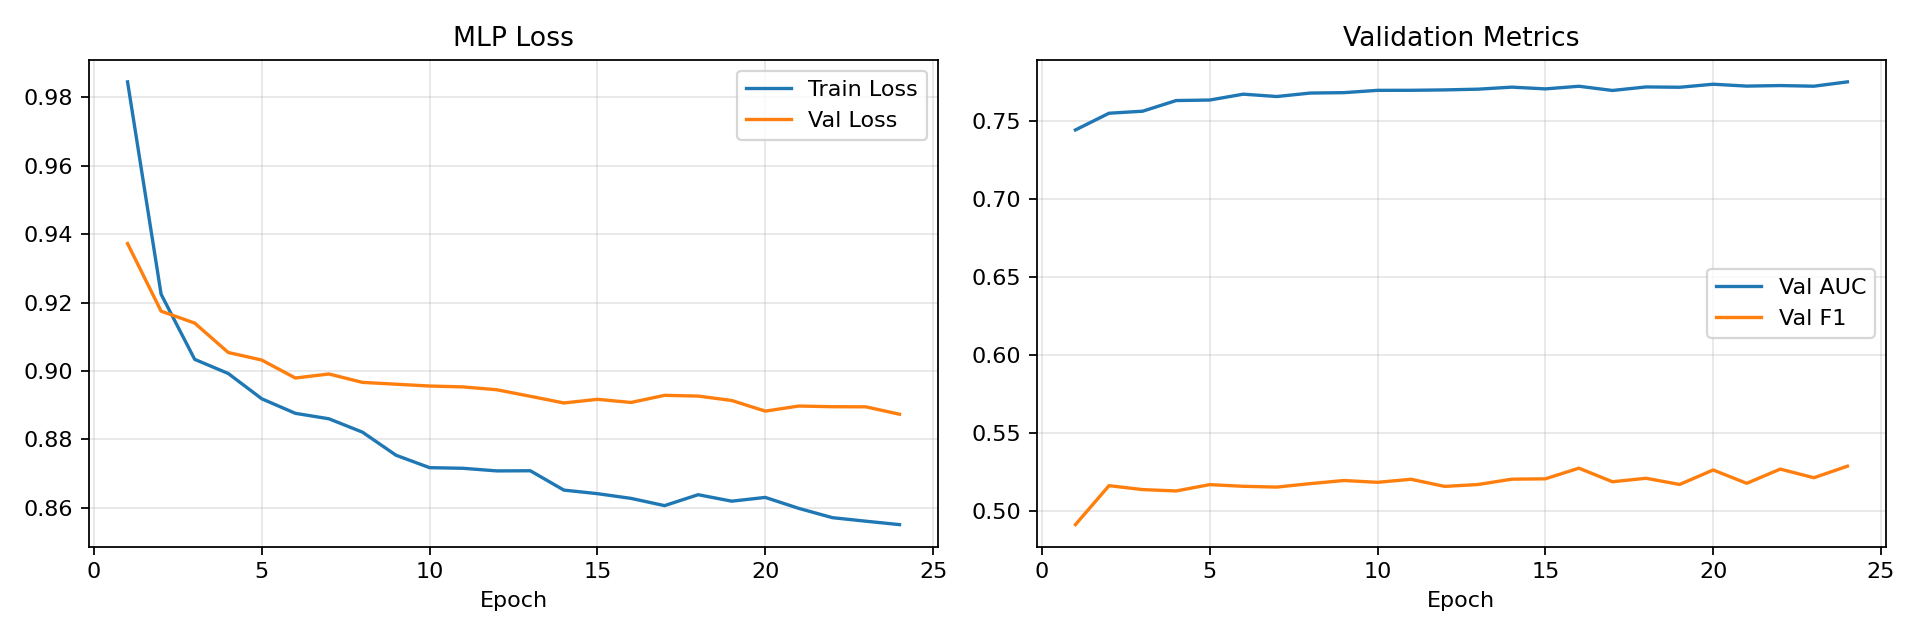

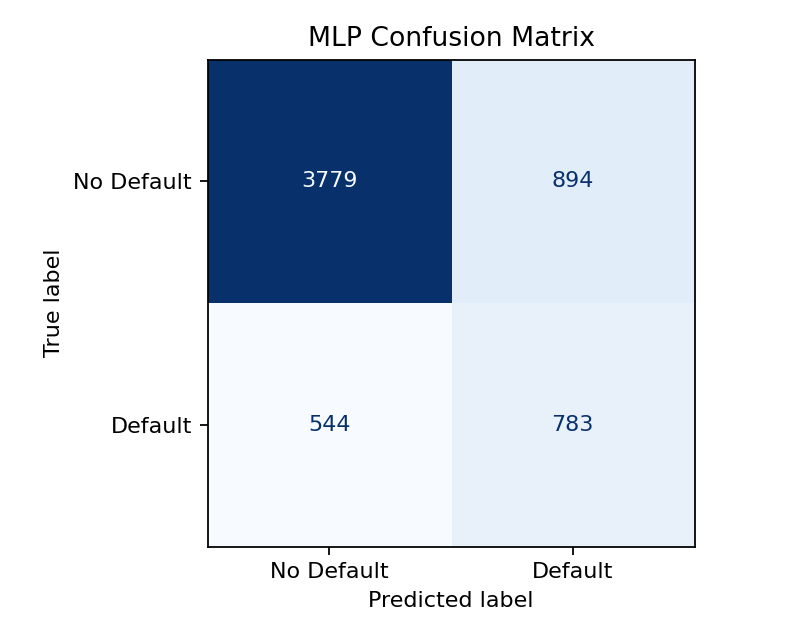

In [8]:
display(Image(filename=str(NOTEBOOK_ASSETS_DIR / 'mlp_training_history.png')))
display(Image(filename=str(NOTEBOOK_ASSETS_DIR / 'mlp_confusion_matrix.png')))

## 6. Tree Models

I trained a random forest as the simpler ensemble baseline, then a CatBoost model with early stopping for the main tree-based result. SHAP is computed on the CatBoost model only.


In [9]:
rf_metrics = json.loads((ARTIFACTS_DIR / 'random_forest_metrics.json').read_text())
catboost_metrics = json.loads((ARTIFACTS_DIR / 'catboost_metrics.json').read_text())

comparison_preview = pd.DataFrame([
    {'model': 'Random Forest', **{k: v for k, v in rf_metrics.items() if k in ['accuracy', 'precision', 'recall', 'f1', 'auc_roc']}},
    {'model': 'CatBoost', **{k: v for k, v in catboost_metrics.items() if k in ['accuracy', 'precision', 'recall', 'f1', 'auc_roc']}},
])
display(comparison_preview)

,model,accuracy,precision,recall,f1,auc_roc
0,Random Forest,0.8130,0.608237,0.434062,0.506596,0.768753
1,CatBoost,0.7695,0.483452,0.616428,0.541901,0.778112


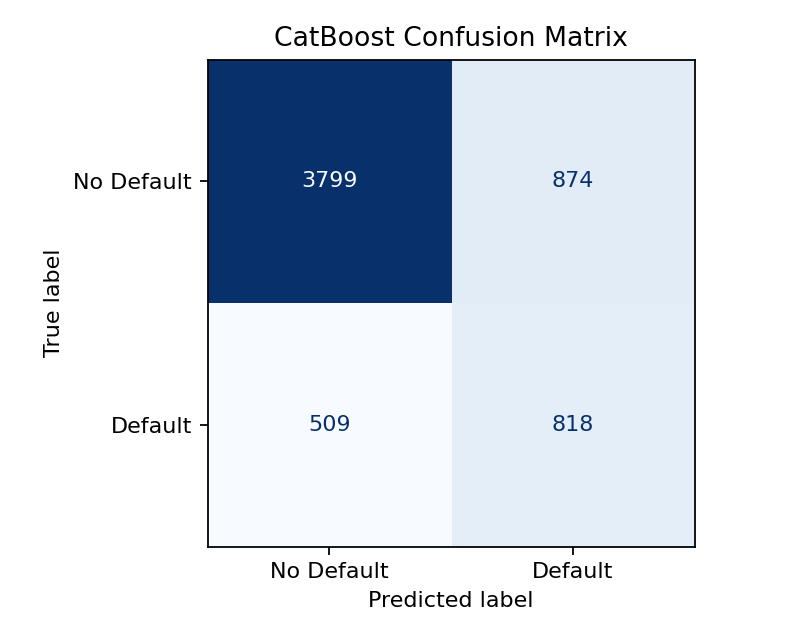

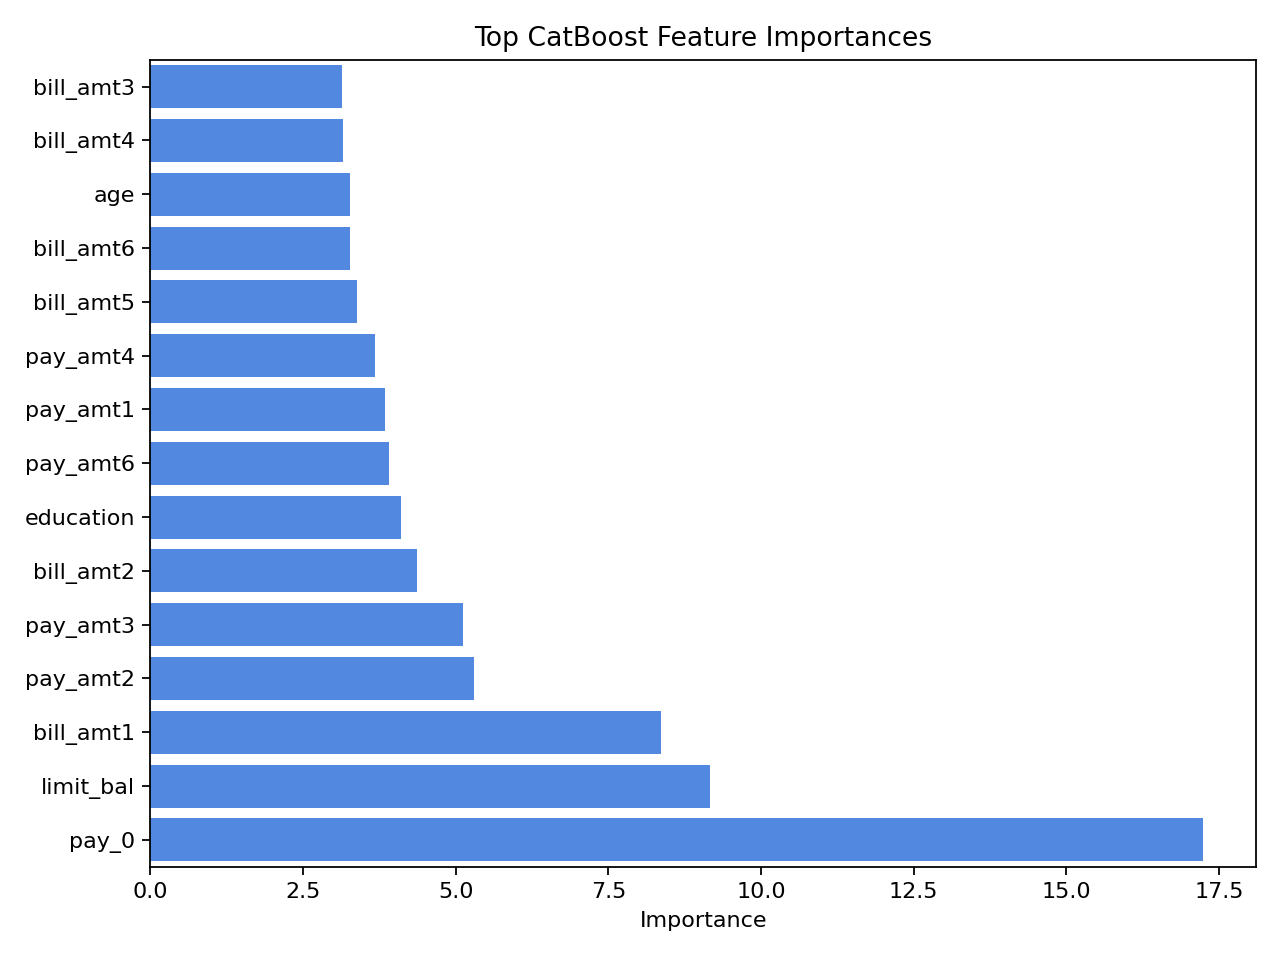

In [10]:
display(Image(filename=str(NOTEBOOK_ASSETS_DIR / 'catboost_confusion_matrix.png')))
display(Image(filename=str(NOTEBOOK_ASSETS_DIR / 'catboost_feature_importance.png')))

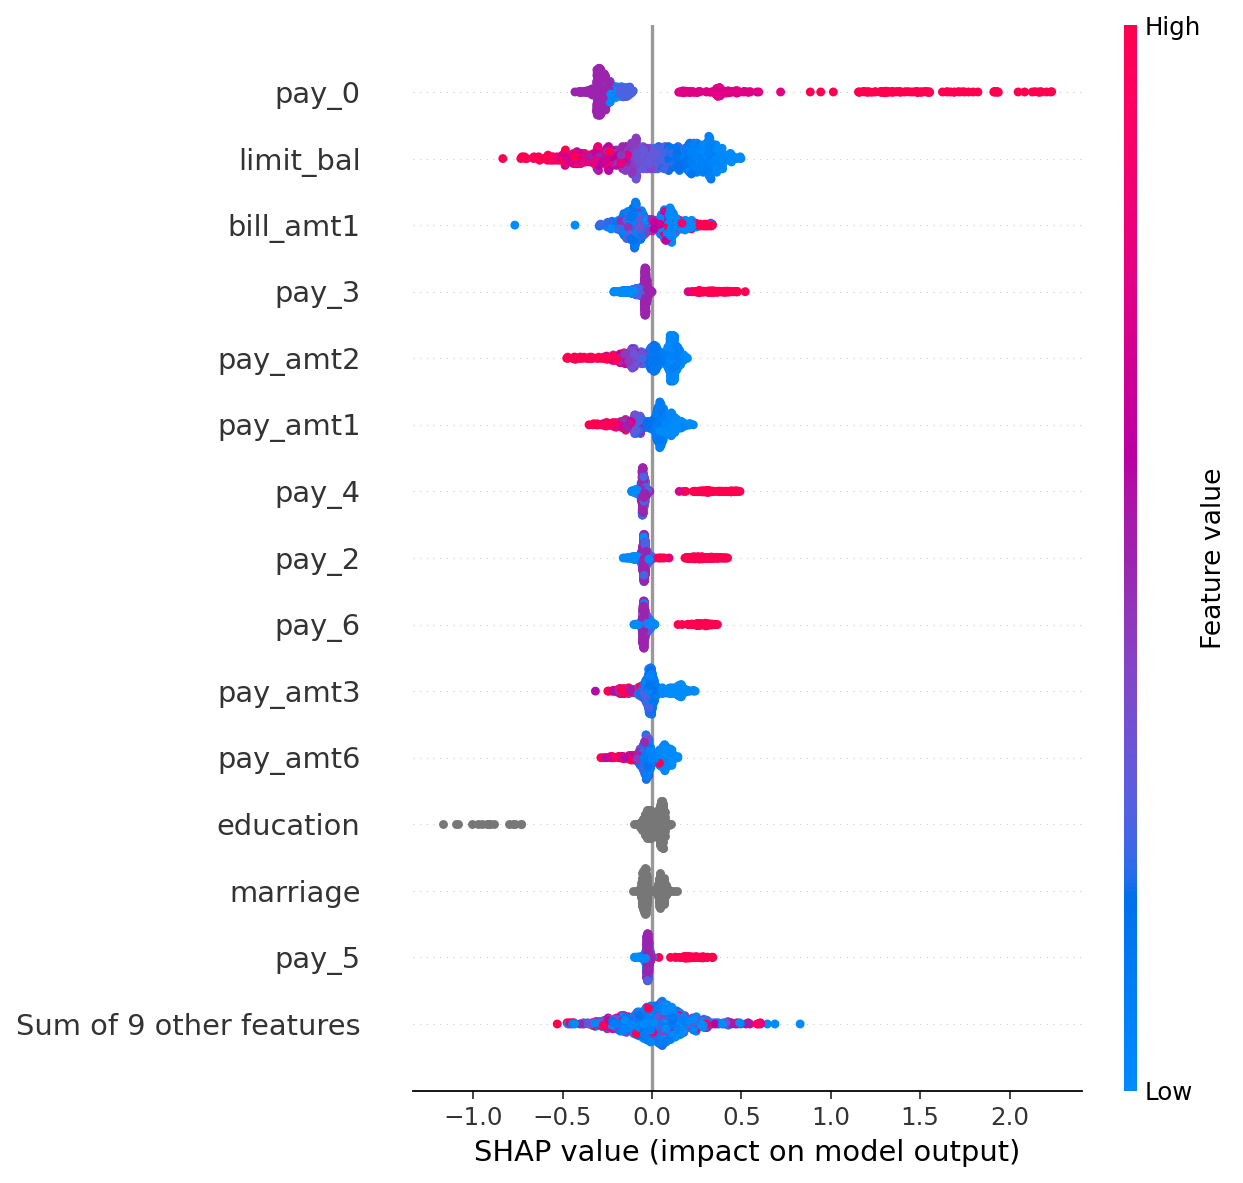

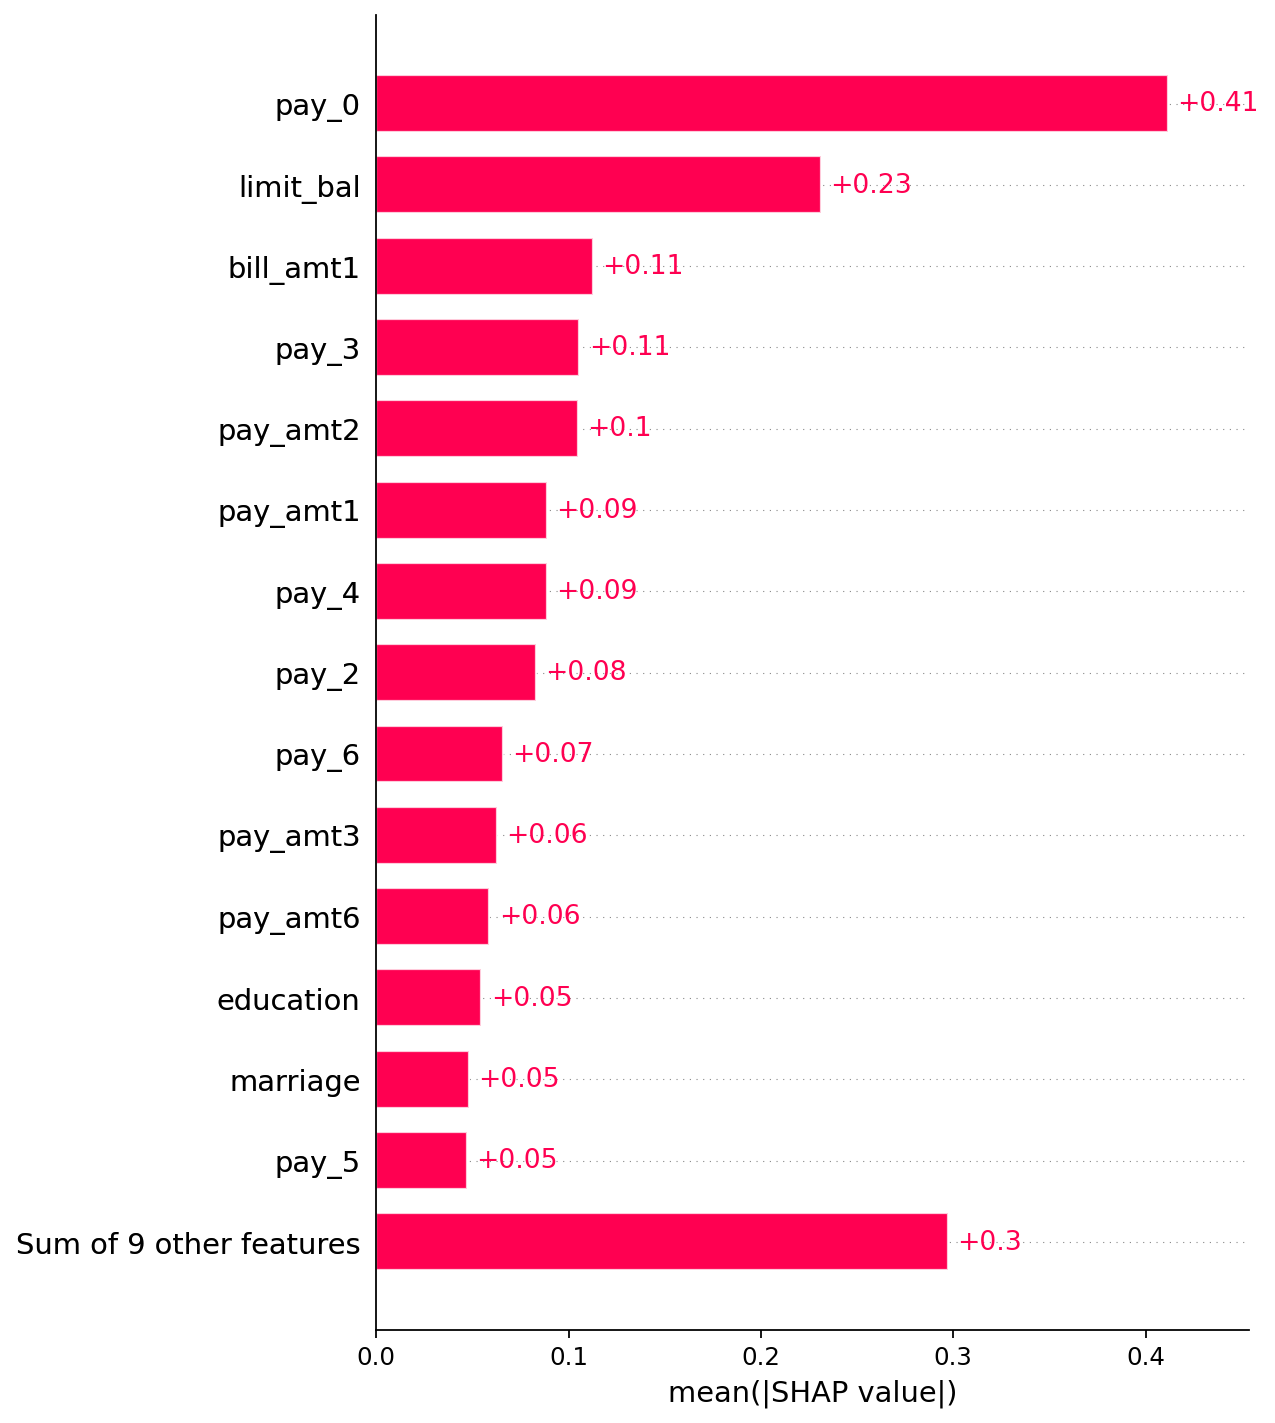

In [11]:
display(Image(filename=str(NOTEBOOK_ASSETS_DIR / 'shap_beeswarm.png')))
display(Image(filename=str(NOTEBOOK_ASSETS_DIR / 'shap_bar.png')))

## 7. Final Comparison

This is the table I would screenshot for the Discord thread. CatBoost ended up with the strongest AUC and F1, while the random forest produced the highest accuracy by being more conservative on the positive class.


In [12]:
comparison_table = pd.read_csv(ARTIFACTS_DIR / 'comparison_table.csv')
display(comparison_table)

,model,accuracy,precision,recall,f1,auc_roc
0,CatBoost,0.769500,0.483452,0.616428,0.541901,0.778112
1,MLP (best config),0.760333,0.466905,0.590053,0.521305,0.772449
2,Random Forest,0.813000,0.608237,0.434062,0.506596,0.768753


## 8. Deployment Notes

The deployment code is in `assignment2_credit_default/api/main.py` and exposes:

- `POST /predict/mlp`
- `POST /predict/tree`

Both endpoints accept the same JSON payload and return a class label plus probability. Before submission, I should still add my own short reflection in my own words to the Discord thread or notebook if I want that extra context to be clearly personal.
